In [1]:
import matplotlib.pyplot as plt
from core.utils import load_run_data
import jax.numpy as jnp

# Use a clean style
plt.style.use('seaborn-v0_8-paper') 


In [2]:
import numpy as np

def normalize_entk_to_cosine(eNTK):
    # 1. Extract the diagonal (the squared L2 norms of each state's gradient)
    #    and take the square root to get the actual norms.
    norms = np.sqrt(np.diag(eNTK))
    
    # 2. Create a denominator matrix where entry (i,j) is norms[i] * norms[j]
    denominator = np.outer(norms, norms)
    
    # 3. Divide the raw eNTK by this denominator (add epsilon to prevent div by zero)
    cosine_sim_matrix = eNTK / (denominator + 1e-12)
    
    return cosine_sim_matrix

In [14]:
from envs.fourrooms import FourRoomsExactValue
import core.helpers as helpers
env, env_params = helpers.make_env(config)
evaluator = FourRoomsExactValue(start_pos = env.pos_fixed, goal_pos = env.goal_fixed, fail_prob= env_params.fail_prob,gamma=config['GAMMA']) 

Env: FourRooms-misc
Default Obs Shape: (13, 13, 2)
Obs Shape: (13, 13, 2)
Action Shape: ()


In [78]:
# def look_at_ntk(run="random_mc_subset/sweep_e_1_sweep_b_100", idx=1000):
#     config, metrics = load_run_data(run, 'FourRooms-misc', 'results')

#     entk = normalize_entk_to_cosine(metrics['eNTK'][0][idx])
#     # plt.matshow(entk[50])
#     # entk[50].shape
#     print(metrics['NTK_rank'][0][idx])

#     plt.imshow(np.abs(evaluator.get_value_grid(entk[0])))
#     # plt.colorbar()

#     plt.imshow(evaluator.get_value_grid(entk[0]))
#     plt.colorbar()

#     plt.matshow(np.abs(normalize_entk_to_cosine(metrics['eNTK'][0][idx])))
#     plt.colorbar()

#     plt.matshow(normalize_entk_to_cosine(metrics['eNTK'][0][idx]))
#     plt.colorbar()

import matplotlib.pyplot as plt
import numpy as np

def look_at_ntk(run="random_mc_subset/sweep_e_1_sweep_b_100", idx=1000):
    config, metrics = load_run_data(run, 'FourRooms-misc', 'results')

    entk = normalize_entk_to_cosine(metrics['eNTK'][0][idx])
    print(metrics['NTK_rank'][0][idx])

    # Create a 1x4 subplot grid (one row, four columns)
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # 1. Absolute value grid
    axes[0].imshow(np.abs(evaluator.get_value_grid(entk[0])))
    axes[0].set_title("Abs Value Grid")

    # 2. Value grid with colorbar
    im2 = axes[1].imshow(evaluator.get_value_grid(entk[0]))
    axes[1].set_title("Value Grid")
    fig.colorbar(im2, ax=axes[1])

    # 3. Absolute eNTK matrix
    axes[2].imshow(np.abs(entk))
    axes[2].set_title("Abs eNTK")

    # 4. eNTK matrix with colorbar
    im4 = axes[3].imshow(entk)
    axes[3].set_title("eNTK")
    fig.colorbar(im4, ax=axes[3])

    plt.tight_layout()
    plt.show()

103


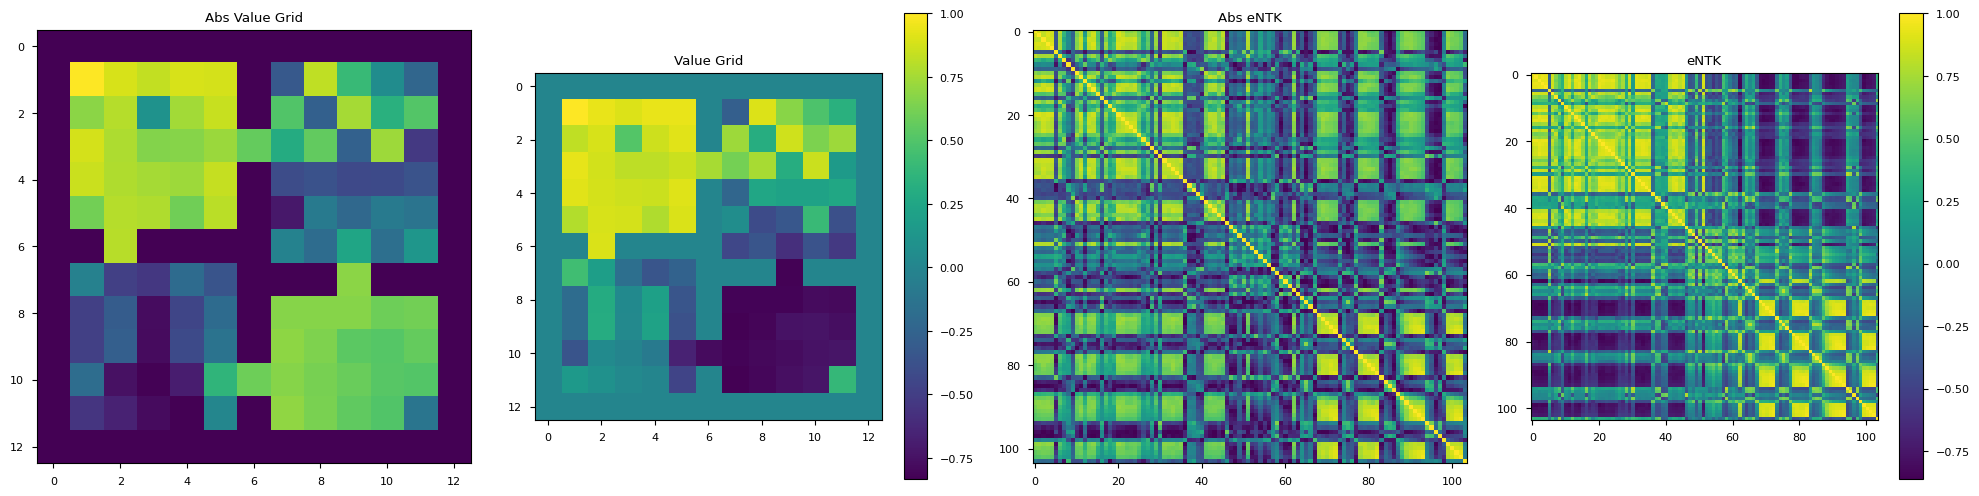

In [79]:
look_at_ntk(run="random_mc_subset/sweep_e_1_sweep_b_100")

68


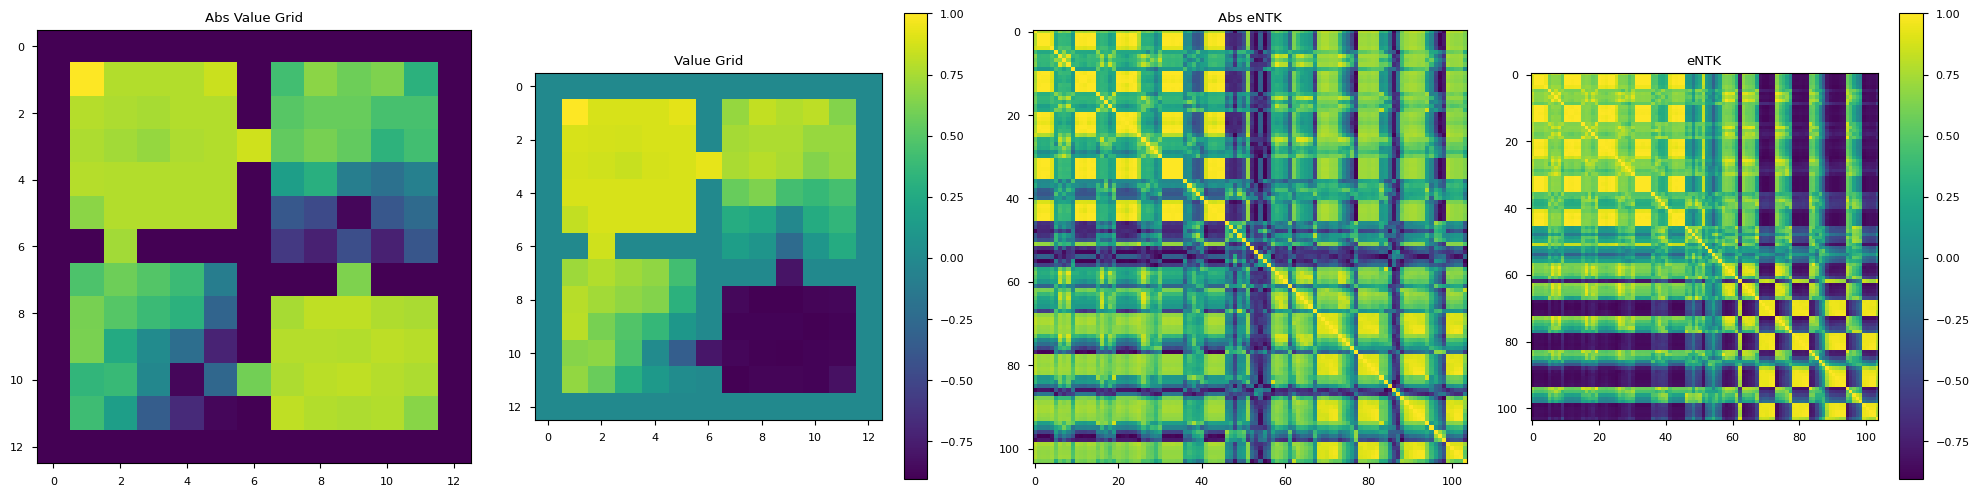

In [80]:
look_at_ntk(run="random_mc_subset/sweep_e_1_sweep_b_4")

103


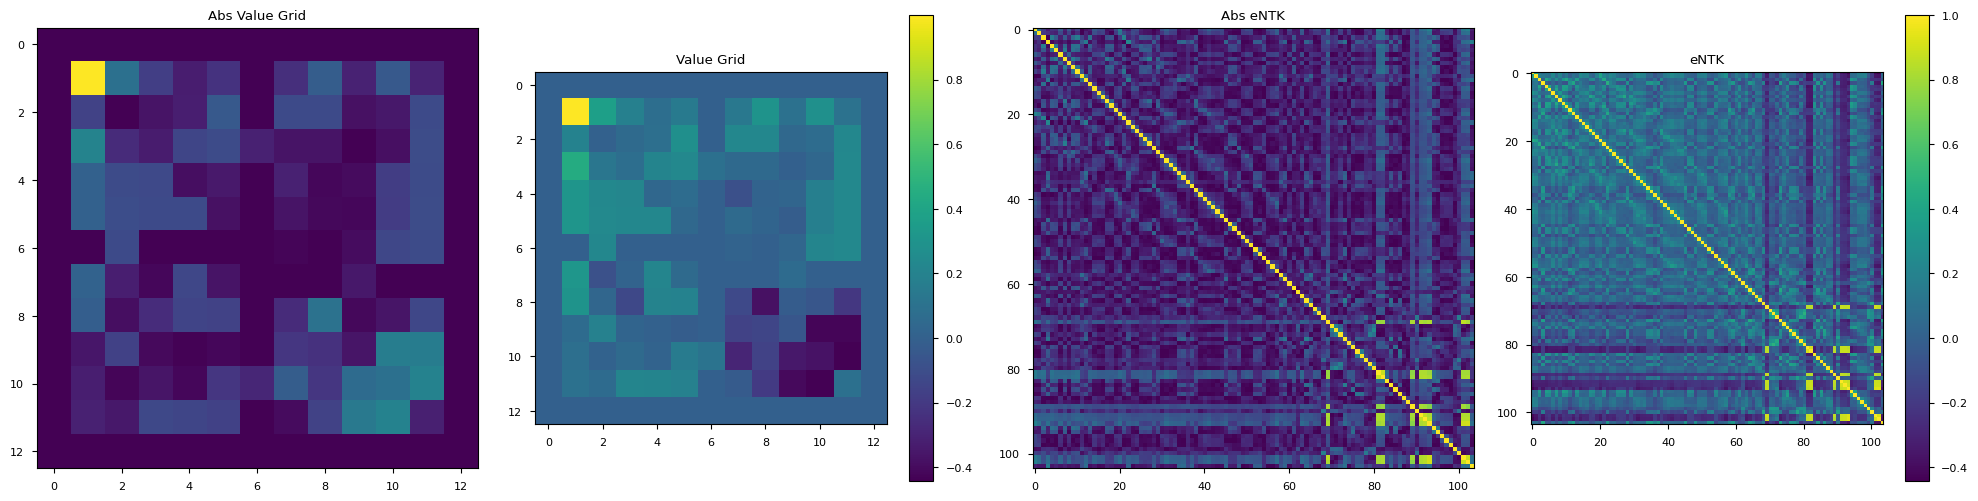

In [81]:
look_at_ntk(run="random_td_subset/sweep_e_1_sweep_b_100")

103


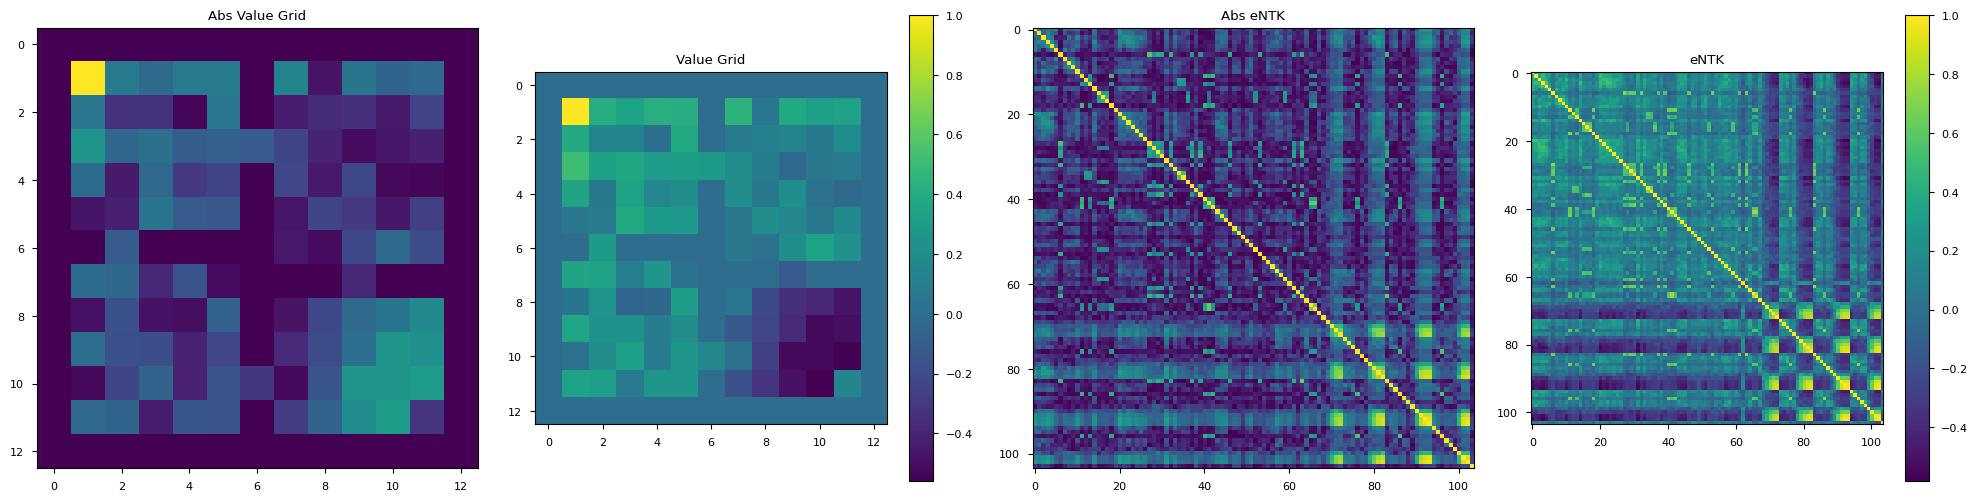

In [82]:
look_at_ntk(run="random_td_subset/sweep_e_1_sweep_b_8")

103


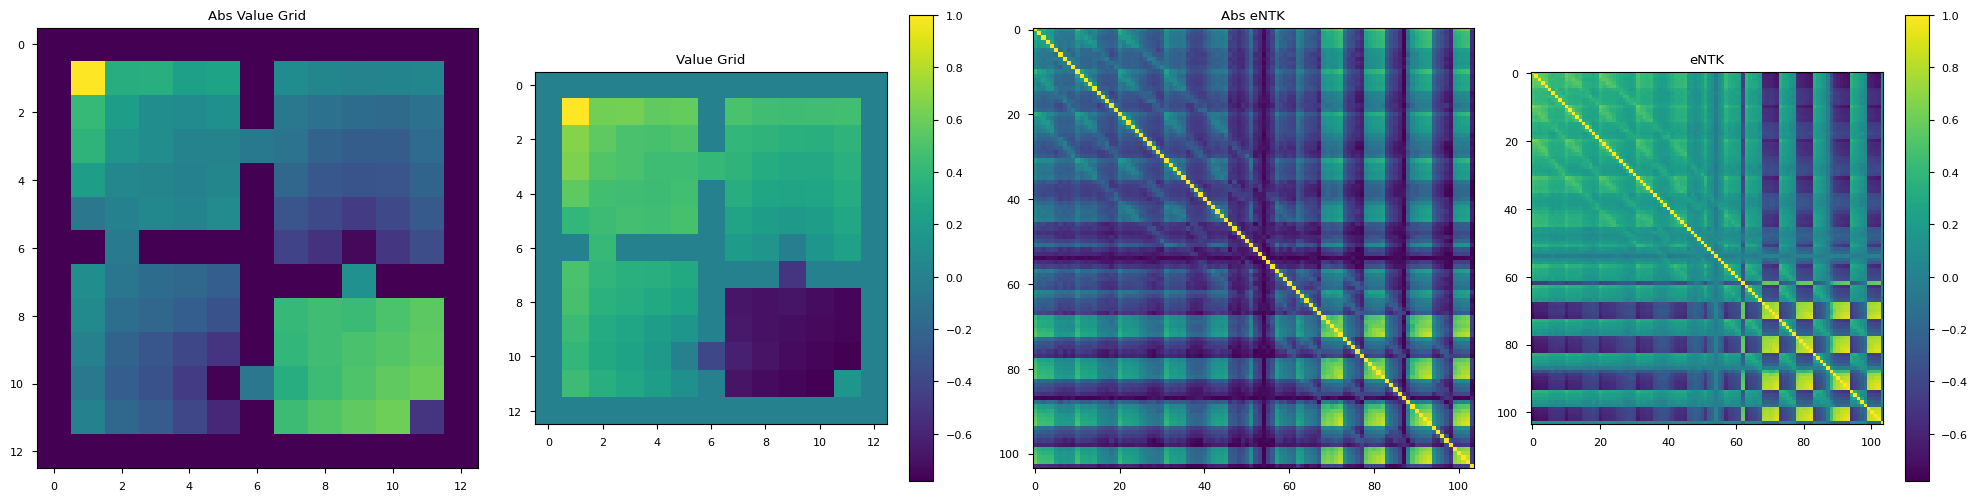

In [83]:
look_at_ntk(run="random_td_subset/sweep_e_4_sweep_b_32")

103


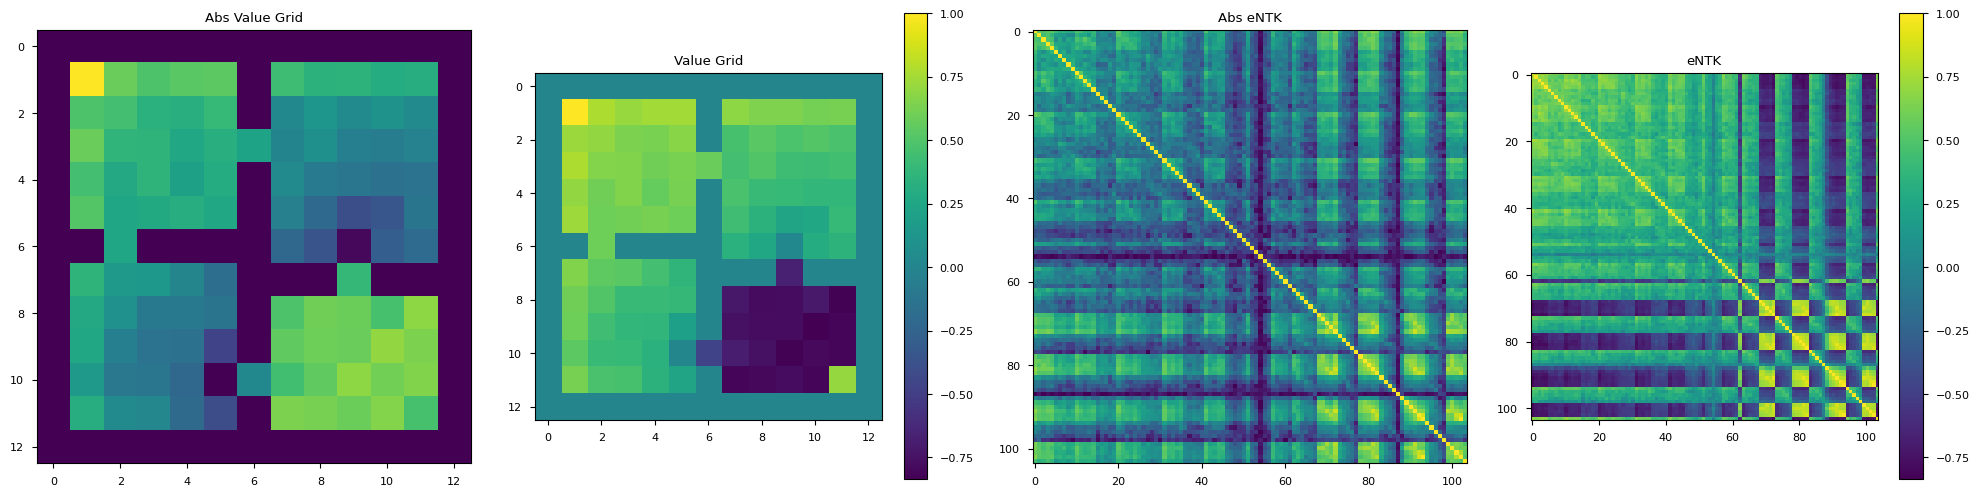

In [84]:
look_at_ntk(run="random_pfqi_subset/sweep_e_4_sweep_b_32")